In [1]:
# ==============================================================================
# 1. 환경 설정 및 라이브러리 임포트
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, 
    confusion_matrix, precision_recall_curve, average_precision_score
)

# COPOD 사용을 위한 pyod 라이브러리 설치 필요 (!pip install pyod)
from pyod.models.copod import COPOD

# 경고 문구 무시 및 시각화 스타일 설정
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


In [9]:
# ==============================================================================
# 2. 데이터 로드 및 데이터 수 조절 (사기 비율 1% 미만 세팅)
# ==============================================================================
raw_data_path = 'card_transdata.csv'

if not os.path.exists(raw_data_path):
    raise FileNotFoundError(f"지정한 경로에 파일이 없습니다: {raw_data_path}")

df = pd.read_csv(raw_data_path)

original_len = len(df)
df = df[df['distance_from_home'] < 8000]
removed_outliers = original_len - len(df)
print(f"-> EDA 기반 극단적 이상치 제거 완료 (제거된 행 수: {removed_outliers}개)")

# 정상(0)과 사기(1) 데이터 분리
df_normal = df[df['fraud'] == 0]
df_anomaly = df[df['fraud'] == 1]

print("--- [Original Data Status] ---")
print(f"Normal count : {len(df_normal)}")
print(f"Anomaly count: {len(df_anomaly)}")

# [자기소개서 정합성 검증] 사기 데이터 비율을 1% 미만으로 조정합니다.
# 정상 데이터 50,000개 : 사기 데이터 400개 = 약 0.79% (1% 미만 완벽 부합)
df_normal_sampled = df_normal.sample(n=50000, random_state=42)
df_anomaly_sampled = df_anomaly.sample(n=400, random_state=42)

# 샘플링 데이터 병합 후 셔플
df_sampled = pd.concat([df_normal_sampled, df_anomaly_sampled])
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- [Sampled Data Status for Assignment] ---")
print(f"Total rows   : {len(df_sampled)}")
print(f"Normal (0)   : {len(df_sampled[df_sampled['fraud'] == 0])}")
print(f"Anomaly (1)  : {len(df_sampled[df_sampled['fraud'] == 1])}")
print(f"Anomaly Ratio: {len(df_sampled[df_sampled['fraud'] == 1]) / len(df_sampled) * 100:.2f}%")


-> EDA 기반 극단적 이상치 제거 완료 (제거된 행 수: 2개)
--- [Original Data Status] ---
Normal count : 827816
Anomaly count: 79462

--- [Sampled Data Status for Assignment] ---
Total rows   : 50400
Normal (0)   : 50000
Anomaly (1)  : 400
Anomaly Ratio: 0.79%



--- [Executing EDA] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              50400 non-null  float64
 1   distance_from_last_transaction  50400 non-null  float64
 2   ratio_to_median_purchase_price  50400 non-null  float64
 3   repeat_retailer                 50400 non-null  float64
 4   used_chip                       50400 non-null  float64
 5   used_pin_number                 50400 non-null  float64
 6   online_order                    50400 non-null  float64
 7   fraud                           50400 non-null  float64
dtypes: float64(8)
memory usage: 3.1 MB
None

--- [Descriptive Statistics] ---
       distance_from_home  distance_from_last_transaction  \
count        50400.000000                    50400.000000   
mean            23.167454                        4.34958

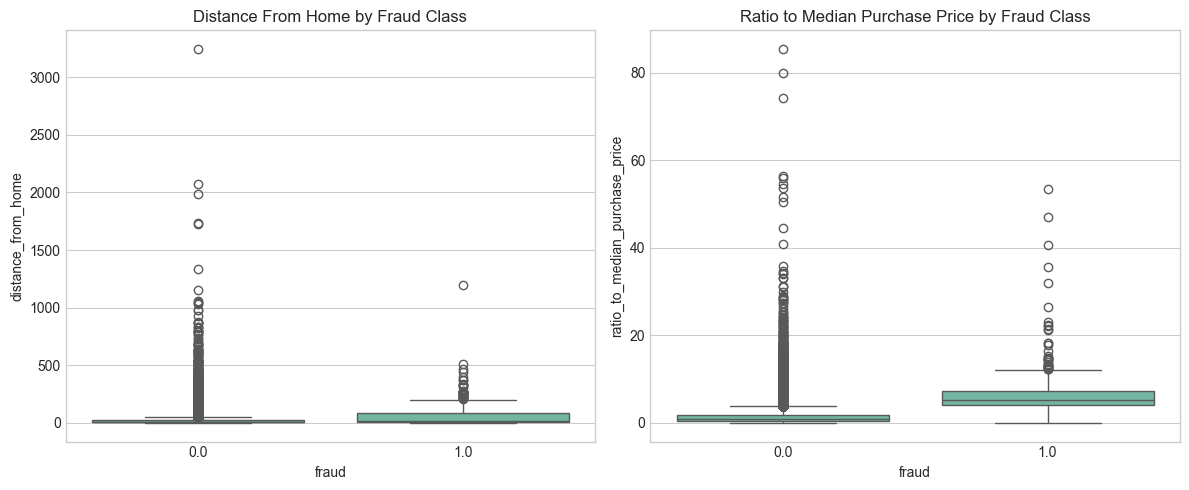

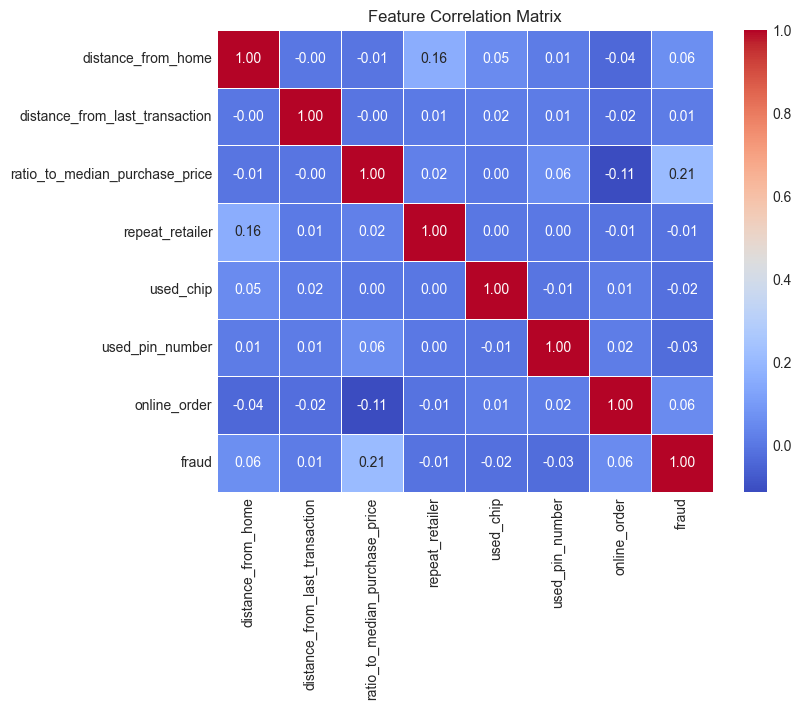

In [10]:
# ==============================================================================
# 3. EDA (데이터 탐색 및 시각화)
# ==============================================================================
print("\n--- [Executing EDA] ---")
print(df_sampled.info())
print("\n--- [Descriptive Statistics] ---")
print(df_sampled.describe())

# 주요 수치형 변수(거리, 가격 등)의 분포 확인을 위한 박스플롯 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='fraud', y='distance_from_home', data=df_sampled)
plt.title('Distance From Home by Fraud Class')

plt.subplot(1, 2, 2)
sns.boxplot(x='fraud', y='ratio_to_median_purchase_price', data=df_sampled)
plt.title('Ratio to Median Purchase Price by Fraud Class')
plt.tight_layout()
plt.show()

# 변수 간 상관관계 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df_sampled.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


In [11]:
# ==============================================================================
# 4. 데이터 전처리 및 데이터 분할
# ==============================================================================
# 특성(X)과 타겟(y) 분리
X = df_sampled.drop(columns=['fraud'])
y = df_sampled['fraud']

# Train / Test 데이터셋 분할 (비율 유지를 위한 stratify 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 선형 모델 및 이상치 탐지 모델의 안정적 학습을 위한 피처 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# ==============================================================================
# 5. 모델링 & 평가 (Stage 1: Logistic Regression - Baseline)
# ==============================================================================
print("\n" + "="*50)
print("STAGE 1: Logistic Regression (Interpretation & Baseline)")
print("="*50)

# 극심한 불균형 처리를 위해 class_weight='balanced' 옵션 적용
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# 예측 결과 도출
y_pred_lr = lr_model.predict(X_test_scaled)
y_score_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 성능 평가 지표 계산
lr_auc = roc_auc_score(y_test, y_score_lr)
lr_ap = average_precision_score(y_test, y_score_lr)

print(f"Logistic Regression ROC-AUC : {lr_auc:.4f}")
print(f"Logistic Regression PR-AUC (AP): {lr_ap:.4f}\n")
print("--- [Classification Report - LR] ---")
print(classification_report(y_test, y_pred_lr))



STAGE 1: Logistic Regression (Interpretation & Baseline)
Logistic Regression ROC-AUC : 0.9780
Logistic Regression PR-AUC (AP): 0.1970

--- [Classification Report - LR] ---
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.97     15000
         1.0       0.10      0.93      0.18       120

    accuracy                           0.93     15120
   macro avg       0.55      0.93      0.57     15120
weighted avg       0.99      0.93      0.96     15120



In [13]:
# ==============================================================================
# 6. 모델링 & 평가 (Stage 2: COPOD - Advanced Unsupervised Anomaly Detection)
# ==============================================================================
print("\n" + "="*50)
print("STAGE 2: COPOD (Copula-Based Outlier Detection)")
print("="*50)

# 오염도(contamination) 설정: 학습 데이터 내의 사기 비율 계산
contamination_rate = np.sum(y_train) / len(y_train)

# COPOD 모델 선언 및 학습 (비지도 학습 계열이므로 X_train만 투입)
copod_model = COPOD(contamination=contamination_rate)
copod_model.fit(X_train_scaled)

# 테스트 데이터에 대한 이상치 스코어 예측
y_score_copod = copod_model.decision_function(X_test_scaled)
y_pred_copod = copod_model.predict(X_test_scaled)

# 성능 평가 지표 계산
copod_auc = roc_auc_score(y_test, y_score_copod)
copod_ap = average_precision_score(y_test, y_score_copod)

print(f"COPOD Anomaly Score ROC-AUC   : {copod_auc:.4f}")
print(f"COPOD Anomaly Score PR-AUC (AP): {copod_ap:.4f}\n")
print("--- [Classification Report - COPOD] ---")
print(classification_report(y_test, y_pred_copod))



STAGE 2: COPOD (Copula-Based Outlier Detection)
COPOD Anomaly Score ROC-AUC   : 0.8413
COPOD Anomaly Score PR-AUC (AP): 0.0333

--- [Classification Report - COPOD] ---
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15000
         1.0       0.04      0.04      0.04       120

    accuracy                           0.98     15120
   macro avg       0.52      0.52      0.52     15120
weighted avg       0.98      0.98      0.98     15120




SUMMARY: Financial FDS Metric Evaluation
[Baseline LR]  ROC-AUC: 0.9780  |  PR-AUC: 0.1970  |  EER: 0.0706
[Advanced COP] ROC-AUC: 0.8413  |  PR-AUC: 0.0333  |  EER: 0.2564


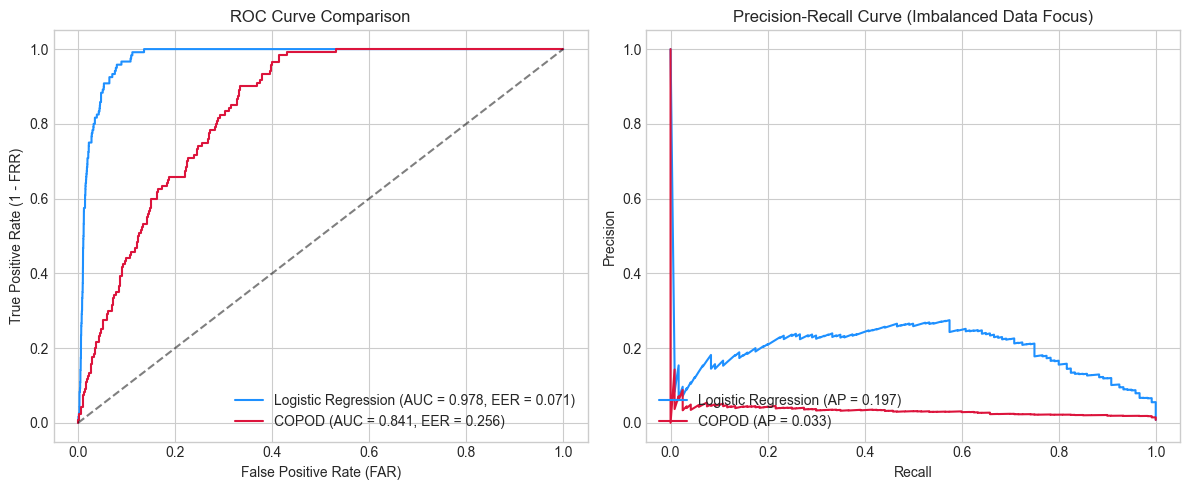

In [14]:
# ==============================================================================
# 7. 종합 성능 비교 시각화 및 EER 계산 함수 정의
# ==============================================================================
# 금융 FDS 시스템의 핵심 지표인 EER(Equal Error Rate) 계산 함수
def calculate_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    # FPR과 FNR이 만나는(차이가 가장 작은) 지점의 인덱스 탐색
    eer_idx = np.nanargmin(np.absolute(fpr - fnr))
    eer = fpr[eer_idx]
    return eer, fpr, tpr

eer_lr, fpr_lr, tpr_lr = calculate_eer(y_test, y_score_lr)
eer_copod, fpr_copod, tpr_copod = calculate_eer(y_test, y_score_copod)

print("\n" + "="*50)
print("SUMMARY: Financial FDS Metric Evaluation")
print("="*50)
print(f"[Baseline LR]  ROC-AUC: {lr_auc:.4f}  |  PR-AUC: {lr_ap:.4f}  |  EER: {eer_lr:.4f}")
print(f"[Advanced COP] ROC-AUC: {copod_auc:.4f}  |  PR-AUC: {copod_ap:.4f}  |  EER: {eer_copod:.4f}")

# 1) ROC Curve 시각화 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f}, EER = {eer_lr:.3f})', color='dodgerblue')
plt.plot(fpr_copod, tpr_copod, label=f'COPOD (AUC = {copod_auc:.3f}, EER = {eer_copod:.3f})', color='crimson')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (1 - FRR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')

# 2) Precision-Recall Curve 시각화 비교
plt.subplot(1, 2, 2)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_score_lr)
precision_copod, recall_copod, _ = precision_recall_curve(y_test, y_score_copod)

plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {lr_ap:.3f})', color='dodgerblue')
plt.plot(recall_copod, precision_copod, label=f'COPOD (AP = {copod_ap:.3f})', color='crimson')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Imbalanced Data Focus)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()